In [1]:
import sys
import time
from pathlib import Path

import astropy.units as u
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.time import Time

sys.path.append(str(Path.cwd().parent))

from src.defaulter import default
from src.eph import get_eph
from src.ephem_table import EphemTable
from src.local_config import get_config


SORA version: 0.3.3


In [2]:
# Get settings
settings = get_config()

# Each family
families = ['is_neo', 'is_mca', 'is_mba', 'is_tjn', 'is_cen', 'is_tno', 'is_ast']

# Get an object for each family
bodies = []
for family in families:
  settings['body']['fields']['family'] = [family]
  settings['body']['id'] = None
  settings = default(settings)
  bodies = bodies + settings['body']['id']
bodies

['2007 RX19',
 '2016 QW1',
 '2008 RC3',
 '2015 HC18',
 '2018 RR2',
 '2015 KZ120',
 '2006 SB368']

In [3]:
# Get 10 time positions for each interval

# Initial date
start = Time("2020-04-11 00:00:00")

# Divisions
intervals = [1 * u.second, 1 * u.minute, 1 * u.hour, 1 * u.day, 1 * u.week, 30 * u.day, 1 * u.year, 10 * u.year]

# Semilla
rng = np.random.default_rng(42)

# Contenedores
ephs = {}
validation_times = {}
interpolated_positions = {}
real_times = {}

# Get ephemerides in time intervals for each body and compute them as well
for body in bodies:
  ephs[body] = []
  validation_times[body] = []
  interpolated_positions[body] = {
    "linear": [],
    "spline3": [],
    "pchip": []
  }
  real_times[body] = []

  for interval in intervals:
    times = start + np.arange(11) * interval

    # Generate validation time inside the interval
    fraction = rng.uniform(0.1, 0.9)
    validation_time = Time(
      times[0].jd + fraction * (times[-1].jd - times[0].jd),
      format="jd"
    )

    # Get ephemerides 11 positions around this date using the specific interval
    eph = get_eph(body, times, ["JPL"])
    
    # Compute position in the random date for each interpolator
    for interpolation in ["linear", "spline3", "pchip"]:
      ephem_table = EphemTable(eph, interpolation=interpolation)
      computing_time = ephem_table.get_position(validation_time)
      interpolated_positions[body][interpolation].append(computing_time)
    
    # Get ephemeris in the random position
    real_eph = get_eph(body, validation_time, ["JPL"])
    real_eph = SkyCoord(
      ra=real_eph['ra'][0] * u.deg,
      dec=real_eph['dec'][0] * u.deg,
      distance=real_eph['distance'][0] * u.au,
      frame="icrs"
    )

    # Save them
    ephs[body].append(eph)
    validation_times[body].append(validation_time)
    real_times[body].append(real_eph)

    time.sleep(1)

d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 2 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 10 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 10 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Un

In [4]:
import pandas as pd

rows = []

interpolations = ["linear", "spline3", "pchip"]

for body in bodies:

  for i, interval in enumerate(intervals):

    validation_time = validation_times[body][i]
    real_position = real_times[body][i]

    for interpolation in interpolations:

      interpolated_position = (
        interpolated_positions[body][interpolation][i]
      )

      # Angular errors
      angular_error = (
        interpolated_position
        .separation(real_position)
        .arcsec
      )

      ra_error = abs(
        (interpolated_position.ra.deg
        - real_position.ra.deg
        + 180) % 360 - 180
      ) * 3600

      dec_error = abs(
        interpolated_position.dec.deg
        - real_position.dec.deg
      ) * 3600

      # Distance errors
      distance_error = abs(
        interpolated_position.distance.au
        - real_position.distance.au
      )

      distance_error_km = (
        distance_error * u.au
      ).to_value(u.km)

      distance_error_pct = (
        distance_error
        / real_position.distance.au
        * 100
      )

      rows.append({
        "body": body,
        "interval": interval,
        "interpolation": interpolation,
        "validation_time": validation_time,
        "angular_error_arcsec": angular_error,
        "ra_error_arcsec": ra_error,
        "dec_error_arcsec": dec_error,
        "distance_error_km": distance_error_km,
        "distance_error_pct": distance_error_pct
      })

results = pd.DataFrame(rows)

In [11]:
results.head(20)

,body,interval,interpolation,validation_time,angular_error_arcsec,ra_error_arcsec,dec_error_arcsec,distance_error_km,distance_error_pct
0,2007 RX19,1.0 s,linear,2458950.5000832365,0.003010,0.006897,0.000000,7.076768e-03,1.677278e-09
1,2007 RX19,1.0 s,spline3,2458950.5000832365,0.002444,0.004831,0.001236,7.074443e-03,1.676727e-09
2,2007 RX19,1.0 s,pchip,2458950.5000832365,0.001509,0.003458,0.000000,7.076768e-03,1.677278e-09
3,2007 RX19,1.0 min,linear,2458950.503132658,0.021758,0.006487,0.021573,6.093599e-03,1.444271e-09
4,2007 RX19,1.0 min,spline3,2458950.503132658,0.020497,0.006351,0.020309,5.951694e-03,1.410637e-09
5,2007 RX19,1.0 min,pchip,2458950.503132658,0.021659,0.006386,0.021479,5.976209e-03,1.416447e-09
6,2007 RX19,1.0 h,linear,2458950.827865973,0.006082,0.005199,0.005644,1.945016e-01,4.615279e-08
7,2007 RX19,1.0 h,spline3,2458950.827865973,0.005778,0.007181,0.004858,1.714416e-03,4.068096e-10
8,2007 RX19,1.0 h,pchip,2458950.827865973,0.006234,0.007252,0.005375,2.051839e-03,4.868757e-10
9,2007 RX19,1.0 d,linear,2458957.0789442323,1.440868,2.828896,0.809256,5.043650e+02,1.223782e-04


In [14]:
summary_by_interval = (
    results
    .groupby(["interval", "interpolation"])["angular_error_arcsec"]
    .agg(
        median="median",
        mean="mean",
        std="std",
        p95=lambda x: x.quantile(0.95),
        max="max"
    )
    .reset_index()
)

summary_by_interval

,interval,interpolation,median,mean,std,p95,max
0,1.0 s,linear,0.015718,0.014326,0.011857,0.030490,0.034742
1,1.0 s,pchip,0.014595,0.013833,0.012846,0.031590,0.035574
2,1.0 s,spline3,0.015326,0.014791,0.011486,0.030994,0.035184
3,1.0 min,linear,0.013077,0.015404,0.007703,0.026859,0.029046
4,1.0 min,pchip,0.013475,0.016115,0.007442,0.027382,0.029835
5,1.0 min,spline3,0.014810,0.016705,0.007378,0.026996,0.029781
6,1.0 h,linear,0.020011,0.018081,0.010146,0.030155,0.032132
7,1.0 h,pchip,0.021358,0.019358,0.010576,0.031826,0.034629
8,1.0 h,spline3,0.022506,0.019798,0.010908,0.032608,0.035699
9,1.0 d,linear,0.338714,0.656398,0.653479,1.600436,1.668823


In [15]:
results_30d = results[results["interval"] == "30.0 d"]

(
    results_30d
    .sort_values("angular_error_arcsec", ascending=False)
    [["body", "interpolation", "angular_error_arcsec"]]
)

,body,interpolation,angular_error_arcsec
159,2006 SB368,linear,3695.712351
161,2006 SB368,pchip,1057.103842
87,2015 HC18,linear,905.841580
39,2016 QW1,linear,655.979234
135,2015 KZ120,linear,536.445958
111,2018 RR2,linear,513.758350
63,2008 RC3,linear,294.786222
89,2015 HC18,pchip,214.342664
41,2016 QW1,pchip,198.914014
65,2008 RC3,pchip,192.875362


In [16]:
for interval in ["1.0 d", "1.0 wk", "30.0 d"]:
    print(f"\n=== {interval} ===")

    print(
        results[results["interval"] == interval]
        .sort_values("angular_error_arcsec", ascending=False)
        [["body", "interpolation", "angular_error_arcsec"]]
        .to_string(index=False)
    )


=== 1.0 d ===
      body interpolation  angular_error_arcsec
  2016 QW1        linear              1.668823
 2007 RX19        linear              1.440868
2015 KZ120        linear              0.721326
 2015 HC18        linear              0.338714
2006 SB368        linear              0.261342
  2018 RR2        linear              0.096257
  2008 RC3        linear              0.067459
  2018 RR2       spline3              0.034526
  2018 RR2         pchip              0.033302
2006 SB368         pchip              0.032056
2006 SB368       spline3              0.027352
  2008 RC3         pchip              0.023572
  2008 RC3       spline3              0.022684
  2016 QW1       spline3              0.019344
 2007 RX19       spline3              0.018128
  2016 QW1         pchip              0.018004
 2007 RX19         pchip              0.017802
2015 KZ120         pchip              0.016282
2015 KZ120       spline3              0.015342
 2015 HC18       spline3              0.01251

In [17]:
evolution = (
    results
    .groupby(["body", "interval", "interpolation"])
    ["angular_error_arcsec"]
    .median()
    .reset_index()
)

In [18]:
evolution_pivot = evolution.pivot_table(
    index=["body", "interval"],
    columns="interpolation",
    values="angular_error_arcsec"
)

evolution_pivot

interpolation               linear          pchip        spline3
body       interval                                             
2006 SB368 1.0 s          0.000000       0.000000       0.004548
           1.0 min        0.005866       0.007107       0.007305
           1.0 h          0.019128       0.022120       0.022732
           1.0 d          0.261342       0.032056       0.027352
           1.0 wk        66.951811       1.888432       0.171848
           30.0 d      3695.712351    1057.103842     162.755798
           1.0 yr     82115.950686   80845.217217   99006.350914
           10.0 yr   151525.104383  162675.175971  130310.381876
2007 RX19  1.0 s          0.003010       0.001509       0.002444
           1.0 min        0.021758       0.021659       0.020497
           1.0 h          0.006082       0.006234       0.005778
           1.0 d          1.440868       0.017802       0.018128
           1.0 wk        58.306679       5.010275       0.134936
           30.0 d       154.124362      86.728168      16.448511
           1.0 yr    154963.521876  150835.511091  140007.953415
           10.0 yr   406181.065292  401605.633969  435793.885256
2008 RC3   1.0 s          0.015718       0.014595       0.015326
           1.0 min        0.015396       0.015517       0.019820
           1.0 h          0.003537       0.004677       0.005142
           1.0 d          0.067459       0.023572       0.022684
           1.0 wk         6.295767       0.919764       0.032261
           30.0 d       294.786222     192.875362       2.262582
           1.0 yr     53346.133932   36701.729805   77625.381394
           10.0 yr   374812.305686  384828.667942  397432.900868
2015 HC18  1.0 s          0.008139       0.004704       0.006692
           1.0 min        0.011625       0.012912       0.014810
           1.0 h          0.020011       0.021202       0.022506
           1.0 d          0.338714       0.011086       0.012511
           1.0 wk        18.431190       0.766057       0.052079
           30.0 d       905.841580     214.342664      27.282572
           1.0 yr     12625.966192   12043.710623   12974.675474
           10.0 yr   333875.022846  327732.229596  343023.792380
2015 KZ120 1.0 s          0.018102       0.018153       0.018128
           1.0 min        0.011059       0.012297       0.011387
           1.0 h          0.025542       0.025286       0.025396
           1.0 d          0.721326       0.016282       0.015342
           1.0 wk        47.227921       1.611502       0.068189
           30.0 d       536.445958      93.747056       2.118712
           1.0 yr      9014.784985    8743.149523    8763.090772
           10.0 yr     1622.301499    1593.636650    1413.005585
2016 QW1   1.0 s          0.034742       0.035574       0.035184
           1.0 min        0.013077       0.013475       0.013336
           1.0 h          0.020136       0.021358       0.021333
           1.0 d          1.668823       0.018004       0.019344
           1.0 wk        37.233178       6.637164       0.028840
           30.0 d       655.979234     198.914014       3.815230
           1.0 yr    172568.290779  181538.245350  169898.823785
           10.0 yr   411130.948412  424028.011146  392427.546886
2018 RR2   1.0 s          0.020570       0.022294       0.021216
           1.0 min        0.029046       0.029835       0.029781
           1.0 h          0.032132       0.034629       0.035699
           1.0 d          0.096257       0.033302       0.034526
           1.0 wk         1.450574       0.193587       0.026748
           30.0 d       513.758350     146.093788       2.767940
           1.0 yr     15753.968108   14540.001937   14513.778275
           10.0 yr     3863.433061    4243.494166    3510.884020

In [19]:
import sys
import time
from pathlib import Path

import astropy.units as u
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.time import Time

sys.path.append(str(Path.cwd().parent))

from src.defaulter import default
from src.eph import get_eph
from src.local_config import get_config

# --------------------------------------------------
# Configuration
# --------------------------------------------------

settings = get_config()

families = [
    'is_neo',
    'is_mca',
    'is_mba',
    'is_tjn',
    'is_cen',
    'is_tno',
    'is_ast'
]

bodies = []

for family in families:
    settings['body']['fields']['family'] = [family]
    settings['body']['id'] = None
    settings = default(settings)
    bodies = bodies + settings['body']['id']


start = Time("2020-04-11 00:00:00")

intervals = [
    1 * u.second,
    1 * u.minute,
    1 * u.hour,
    1 * u.day,
    1 * u.week,
    30 * u.day,
    1 * u.year,
    10 * u.year
]

interval_labels = [
    "1 s",
    "1 min",
    "1 h",
    "1 d",
    "1 wk",
    "30 d",
    "1 yr",
    "10 yr"
]

interpolations = [
    "linear",
    "spline3",
    "pchip"
]

# --------------------------------------------------
# Validation points
# --------------------------------------------------

rng = np.random.default_rng(42)

n_validation_points = 10

validation_fractions = np.sort(
    rng.uniform(
        0.1,
        0.9,
        n_validation_points
    )
)

# --------------------------------------------------
# Storage
# --------------------------------------------------

interpolated_positions = {}
real_positions = {}
validation_times = {}

# --------------------------------------------------
# Generate ephemerides and positions
# --------------------------------------------------

for body in bodies:

    print(f"Processing {body}...")

    interpolated_positions[body] = {
        interpolation: []
        for interpolation in interpolations
    }

    real_positions[body] = []
    validation_times[body] = []

    for interval in intervals:

        # 11 points -> 10 equal intervals
        times = start + np.arange(11) * interval

        # Generate ephemeris table
        eph = get_eph(
            body,
            times,
            ["JPL"]
        )

        # Generate the 10 validation times
        body_validation_times = [
            Time(
                times[0].jd
                + fraction * (
                    times[-1].jd
                    - times[0].jd
                ),
                format="jd"
            )
            for fraction in validation_fractions
        ]

        for validation_time in body_validation_times:

            validation_times[body].append(
                validation_time
            )

            # --------------------------------------
            # Interpolated positions
            # --------------------------------------

            for interpolation in interpolations:

                ephem_table = EphemTable(
                    eph,
                    interpolation=interpolation
                )

                position = ephem_table.get_position(
                    validation_time
                )

                interpolated_positions[
                    body
                ][interpolation].append(
                    position
                )

            # --------------------------------------
            # Reference position
            # --------------------------------------

            real_eph = get_eph(
                body,
                validation_time,
                ["JPL"]
            )

            real_position = SkyCoord(
                ra=real_eph["ra"][0] * u.deg,
                dec=real_eph["dec"][0] * u.deg,
                distance=real_eph["distance"][0] * u.au,
                frame="icrs"
            )

            real_positions[body].append(
                real_position
            )

        # Avoid hammering the service
        time.sleep(1)

Processing 2013 JM7...


d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 2 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 10 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 10 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Processing 2003 NW...


d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 2 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 10 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 10 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Processing 2005 TL84...


...

d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 2 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 10 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 10 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Processing 2020 CM3...


d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 2 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 10 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 10 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Processing 2009 BU142...


d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 2 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 10 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 10 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [20]:
rows = []

n_points = n_validation_points

for body in bodies:

    for interval_index, interval_label in enumerate(interval_labels):

        start_index = interval_index * n_points
        end_index = start_index + n_points

        body_validation_times = validation_times[body][
            start_index:end_index
        ]

        body_real_positions = real_positions[body][
            start_index:end_index
        ]

        for point_index in range(n_points):

            validation_time = body_validation_times[
                point_index
            ]

            real_position = body_real_positions[
                point_index
            ]

            for interpolation in interpolations:

                interpolated_position = (
                    interpolated_positions[body][interpolation][
                        start_index + point_index
                    ]
                )

                angular_error = (
                    interpolated_position
                    .separation(real_position)
                    .arcsec
                )

                ra_error = abs(
                    (
                        interpolated_position.ra.deg
                        - real_position.ra.deg
                        + 180
                    ) % 360 - 180
                ) * 3600

                dec_error = abs(
                    interpolated_position.dec.deg
                    - real_position.dec.deg
                ) * 3600

                distance_error = abs(
                    interpolated_position.distance.au
                    - real_position.distance.au
                )

                distance_error_km = (
                    distance_error * u.au
                ).to_value(u.km)

                distance_error_pct = (
                    distance_error
                    / real_position.distance.au
                    * 100
                )

                rows.append({
                    "body": body,
                    "interval": interval_label,
                    "interpolation": interpolation,
                    "validation_time": validation_time,
                    "angular_error_arcsec": angular_error,
                    "ra_error_arcsec": ra_error,
                    "dec_error_arcsec": dec_error,
                    "distance_error_km": distance_error_km,
                    "distance_error_pct": distance_error_pct
                })


results = pd.DataFrame(rows)

In [21]:
summary = (
    results
    .groupby(["interval", "interpolation"])
    ["angular_error_arcsec"]
    .agg(
        median="median",
        mean="mean",
        std="std",
        p95=lambda x: x.quantile(0.95),
        max="max"
    )
    .reset_index()
)

summary

,interval,interpolation,median,mean,std,p95,max
0,1 d,linear,0.353279,0.934350,0.978138,2.779634,3.525471
1,1 d,pchip,0.018550,0.020057,0.010621,0.038877,0.051784
2,1 d,spline3,0.015158,0.016303,0.006732,0.028483,0.035314
3,1 h,linear,0.015530,0.016848,0.007656,0.030786,0.033292
4,1 h,pchip,0.015745,0.017442,0.008388,0.032165,0.035651
5,1 h,spline3,0.016411,0.017557,0.008423,0.031993,0.035447
6,1 min,linear,0.011875,0.014034,0.009091,0.028877,0.038024
7,1 min,pchip,0.012453,0.014481,0.009654,0.029600,0.038390
8,1 min,spline3,0.012734,0.014622,0.009639,0.029284,0.038152
9,1 s,linear,0.000000,0.005218,0.009188,0.026440,0.032946


In [ ]:
summary_by_body = (
    results
    .groupby(["body", "interval", "interpolation"])
    ["angular_error_arcsec"]
    .agg(
        median="median",
        mean="mean",
        p95=lambda x: x.quantile(0.95),
        max="max"
    )
    .reset_index()
)

,body,interval,interpolation,median,mean,p95,max
0,2003 NW,1 d,linear,2.418928,2.334659,3.483596,3.525471
1,2003 NW,1 d,pchip,0.028790,0.028985,0.046209,0.051784
2,2003 NW,1 d,spline3,0.016786,0.018932,0.032986,0.035314
3,2003 NW,1 h,linear,0.014392,0.017465,0.032241,0.033292
4,2003 NW,1 h,pchip,0.011975,0.015637,0.033985,0.034635
...,...,...,...,...,...,...,...
163,2020 CM3,10 yr,pchip,1235.519062,2144.269577,5508.017806,5806.891679
164,2020 CM3,10 yr,spline3,1219.914061,2164.788435,5588.519988,5990.248719
165,2020 CM3,30 d,linear,83.698177,79.787741,143.535416,145.684232
166,2020 CM3,30 d,pchip,28.188650,31.752474,70.254549,77.942965


In [26]:
for i in summary_by_body["body"].unique():
  display(summary_by_body[summary_by_body["body"] == i])

,body,interval,interpolation,median,mean,p95,max
0,2003 NW,1 d,linear,2.418928e+00,2.334659,3.483596,3.525471
1,2003 NW,1 d,pchip,2.879049e-02,0.028985,0.046209,0.051784
2,2003 NW,1 d,spline3,1.678556e-02,0.018932,0.032986,0.035314
3,2003 NW,1 h,linear,1.439232e-02,0.017465,0.032241,0.033292
4,2003 NW,1 h,pchip,1.197508e-02,0.015637,0.033985,0.034635
5,2003 NW,1 h,spline3,1.225878e-02,0.015762,0.034114,0.034700
6,2003 NW,1 min,linear,1.116960e-02,0.013712,0.025146,0.025665
7,2003 NW,1 min,pchip,9.437122e-03,0.013789,0.026078,0.026895
8,2003 NW,1 min,spline3,9.224884e-03,0.013576,0.026812,0.028477
9,2003 NW,1 s,linear,5.063366e-11,0.009709,0.031572,0.032946


,body,interval,interpolation,median,mean,p95,max
24,2005 TL84,1 d,linear,0.543306,0.514177,0.774010,0.792689
25,2005 TL84,1 d,pchip,0.017147,0.015937,0.024902,0.027843
26,2005 TL84,1 d,spline3,0.014105,0.014713,0.024303,0.025183
27,2005 TL84,1 h,linear,0.017624,0.019350,0.027794,0.028505
28,2005 TL84,1 h,pchip,0.017538,0.020120,0.029017,0.029348
29,2005 TL84,1 h,spline3,0.017955,0.020397,0.029567,0.030241
30,2005 TL84,1 min,linear,0.014146,0.014354,0.021422,0.021788
31,2005 TL84,1 min,pchip,0.015239,0.015091,0.021782,0.022079
32,2005 TL84,1 min,spline3,0.015117,0.015279,0.022270,0.022819
33,2005 TL84,1 s,linear,0.000375,0.007606,0.021528,0.024268


,body,interval,interpolation,median,mean,p95,max
48,2009 BU142,1 d,linear,1.721709,1.641532,2.497227,2.537373
49,2009 BU142,1 d,pchip,0.022655,0.022237,0.037544,0.038091
50,2009 BU142,1 d,spline3,0.014365,0.015363,0.024283,0.025945
51,2009 BU142,1 h,linear,0.012833,0.012763,0.018839,0.019045
52,2009 BU142,1 h,pchip,0.012317,0.012828,0.021186,0.022880
53,2009 BU142,1 h,spline3,0.012021,0.012548,0.020709,0.021974
54,2009 BU142,1 min,linear,0.016598,0.015922,0.030198,0.035995
55,2009 BU142,1 min,pchip,0.016757,0.016880,0.030978,0.036282
56,2009 BU142,1 min,spline3,0.015981,0.016871,0.030960,0.036278
57,2009 BU142,1 s,linear,0.000000,0.004128,0.021226,0.026482


,body,interval,interpolation,median,mean,p95,max
72,2013 CA215,1 d,linear,0.229424,0.225769,0.327326,0.338275
73,2013 CA215,1 d,pchip,0.014674,0.016846,0.026848,0.031774
74,2013 CA215,1 d,spline3,0.015931,0.017687,0.028129,0.032901
75,2013 CA215,1 h,linear,0.016194,0.015457,0.026696,0.028131
76,2013 CA215,1 h,pchip,0.016981,0.016738,0.028490,0.029338
77,2013 CA215,1 h,spline3,0.016928,0.017337,0.029128,0.029194
78,2013 CA215,1 min,linear,0.023858,0.021575,0.033951,0.038024
79,2013 CA215,1 min,pchip,0.025733,0.022236,0.034514,0.038390
80,2013 CA215,1 min,spline3,0.026180,0.022614,0.034208,0.038152
81,2013 CA215,1 s,linear,0.000000,0.002521,0.008814,0.010383


,body,interval,interpolation,median,mean,p95,max
96,2013 JM7,1 d,linear,1.526860,1.470731,2.198946,2.217686
97,2013 JM7,1 d,pchip,0.020508,0.020876,0.037951,0.042534
98,2013 JM7,1 d,spline3,0.014903,0.016856,0.028483,0.029099
99,2013 JM7,1 h,linear,0.015269,0.016675,0.029019,0.032797
100,2013 JM7,1 h,pchip,0.016589,0.018597,0.031765,0.035651
101,2013 JM7,1 h,spline3,0.016708,0.019073,0.031520,0.035447
102,2013 JM7,1 min,linear,0.015242,0.016038,0.028796,0.029640
103,2013 JM7,1 min,pchip,0.015953,0.016442,0.029707,0.031081
104,2013 JM7,1 min,spline3,0.016284,0.016676,0.030020,0.031766
105,2013 JM7,1 s,linear,0.010369,0.012563,0.025730,0.026390


,body,interval,interpolation,median,mean,p95,max
120,2014 DB143,1 d,linear,0.241503,0.230707,0.346197,0.358472
121,2014 DB143,1 d,pchip,0.012578,0.012080,0.019616,0.020699
122,2014 DB143,1 d,spline3,0.012732,0.012521,0.020372,0.021450
123,2014 DB143,1 h,linear,0.018606,0.019403,0.031207,0.031722
124,2014 DB143,1 h,pchip,0.019851,0.020491,0.032165,0.032247
125,2014 DB143,1 h,spline3,0.019909,0.020581,0.031993,0.032178
126,2014 DB143,1 min,linear,0.007222,0.009034,0.020746,0.025730
127,2014 DB143,1 min,pchip,0.007814,0.009359,0.021451,0.025730
128,2014 DB143,1 min,spline3,0.007591,0.009252,0.020991,0.025049
129,2014 DB143,1 s,linear,0.000000,0.000000,0.000000,0.000000


,body,interval,interpolation,median,mean,p95,max
144,2020 CM3,1 d,linear,0.137541,0.122877,0.185446,0.194806
145,2020 CM3,1 d,pchip,0.021364,0.023440,0.039559,0.045087
146,2020 CM3,1 d,spline3,0.016840,0.018048,0.025572,0.026867
147,2020 CM3,1 h,linear,0.019815,0.016825,0.026416,0.027200
148,2020 CM3,1 h,pchip,0.021048,0.017681,0.028058,0.028677
149,2020 CM3,1 h,spline3,0.019347,0.017204,0.028409,0.028900
150,2020 CM3,1 min,linear,0.007322,0.007606,0.015723,0.017076
151,2020 CM3,1 min,pchip,0.006245,0.007569,0.019614,0.021343
152,2020 CM3,1 min,spline3,0.006856,0.008085,0.019740,0.021319
153,2020 CM3,1 s,linear,0.000000,0.000000,0.000000,0.000000


In [27]:
interval_seconds = {
    "1 s": 1,
    "1 min": 60,
    "1 h": 60 * 60,
    "1 d": 24 * 60 * 60,
    "1 wk": 7 * 24 * 60 * 60,
    "30 d": 30 * 24 * 60 * 60,
    "1 yr": 365.25 * 24 * 60 * 60,
    "10 yr": 10 * 365.25 * 24 * 60 * 60,
}

results["interval_seconds"] = results["interval"].map(interval_seconds)

results["interval_days"] = results["interval_seconds"] / (24 * 60 * 60)

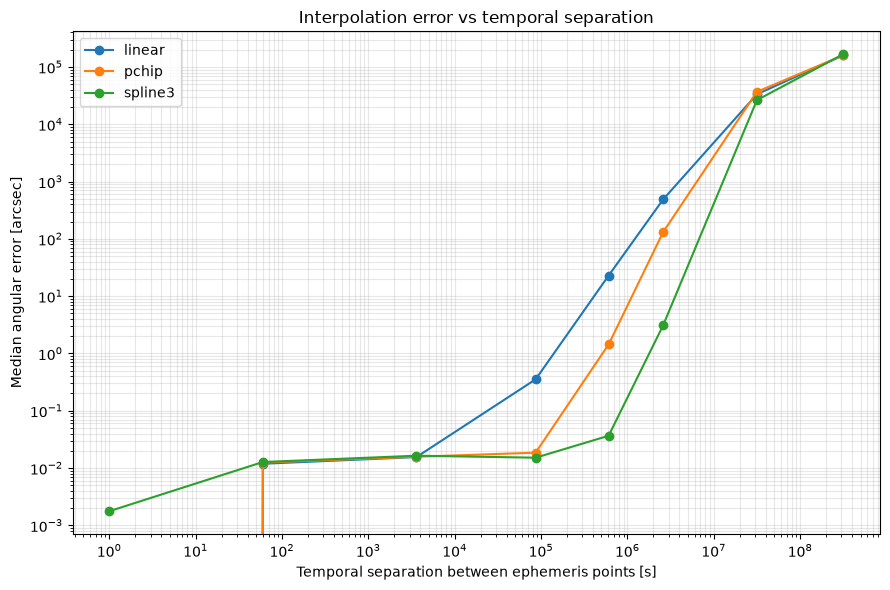

In [28]:
import matplotlib.pyplot as plt

summary = (
    results
    .groupby(["interval_seconds", "interpolation"])
    ["angular_error_arcsec"]
    .median()
    .reset_index()
)


plt.figure(figsize=(9, 6))

for interpolation in ["linear", "pchip", "spline3"]:
    data = summary[
        summary["interpolation"] == interpolation
    ].sort_values("interval_seconds")

    plt.plot(
        data["interval_seconds"],
        data["angular_error_arcsec"],
        marker="o",
        label=interpolation
    )


plt.xscale("log")
plt.yscale("log")

plt.xlabel("Temporal separation between ephemeris points [s]")
plt.ylabel("Median angular error [arcsec]")
plt.title("Interpolation error vs temporal separation")

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

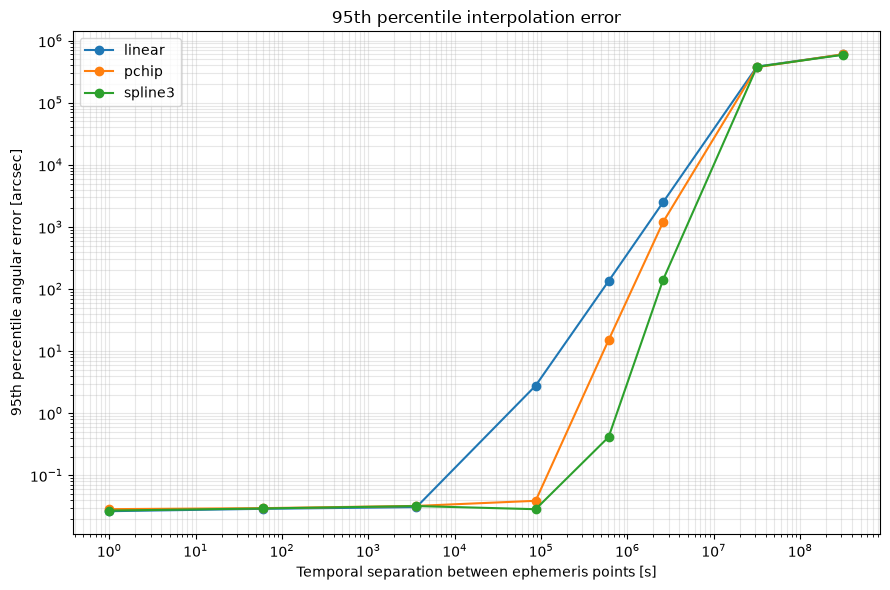

In [29]:
summary_p95 = (
    results
    .groupby(["interval_seconds", "interpolation"])
    ["angular_error_arcsec"]
    .quantile(0.95)
    .reset_index()
)


plt.figure(figsize=(9, 6))

for interpolation in ["linear", "pchip", "spline3"]:
    data = summary_p95[
        summary_p95["interpolation"] == interpolation
    ].sort_values("interval_seconds")

    plt.plot(
        data["interval_seconds"],
        data["angular_error_arcsec"],
        marker="o",
        label=interpolation
    )


plt.xscale("log")
plt.yscale("log")

plt.xlabel("Temporal separation between ephemeris points [s]")
plt.ylabel("95th percentile angular error [arcsec]")
plt.title("95th percentile interpolation error")

plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

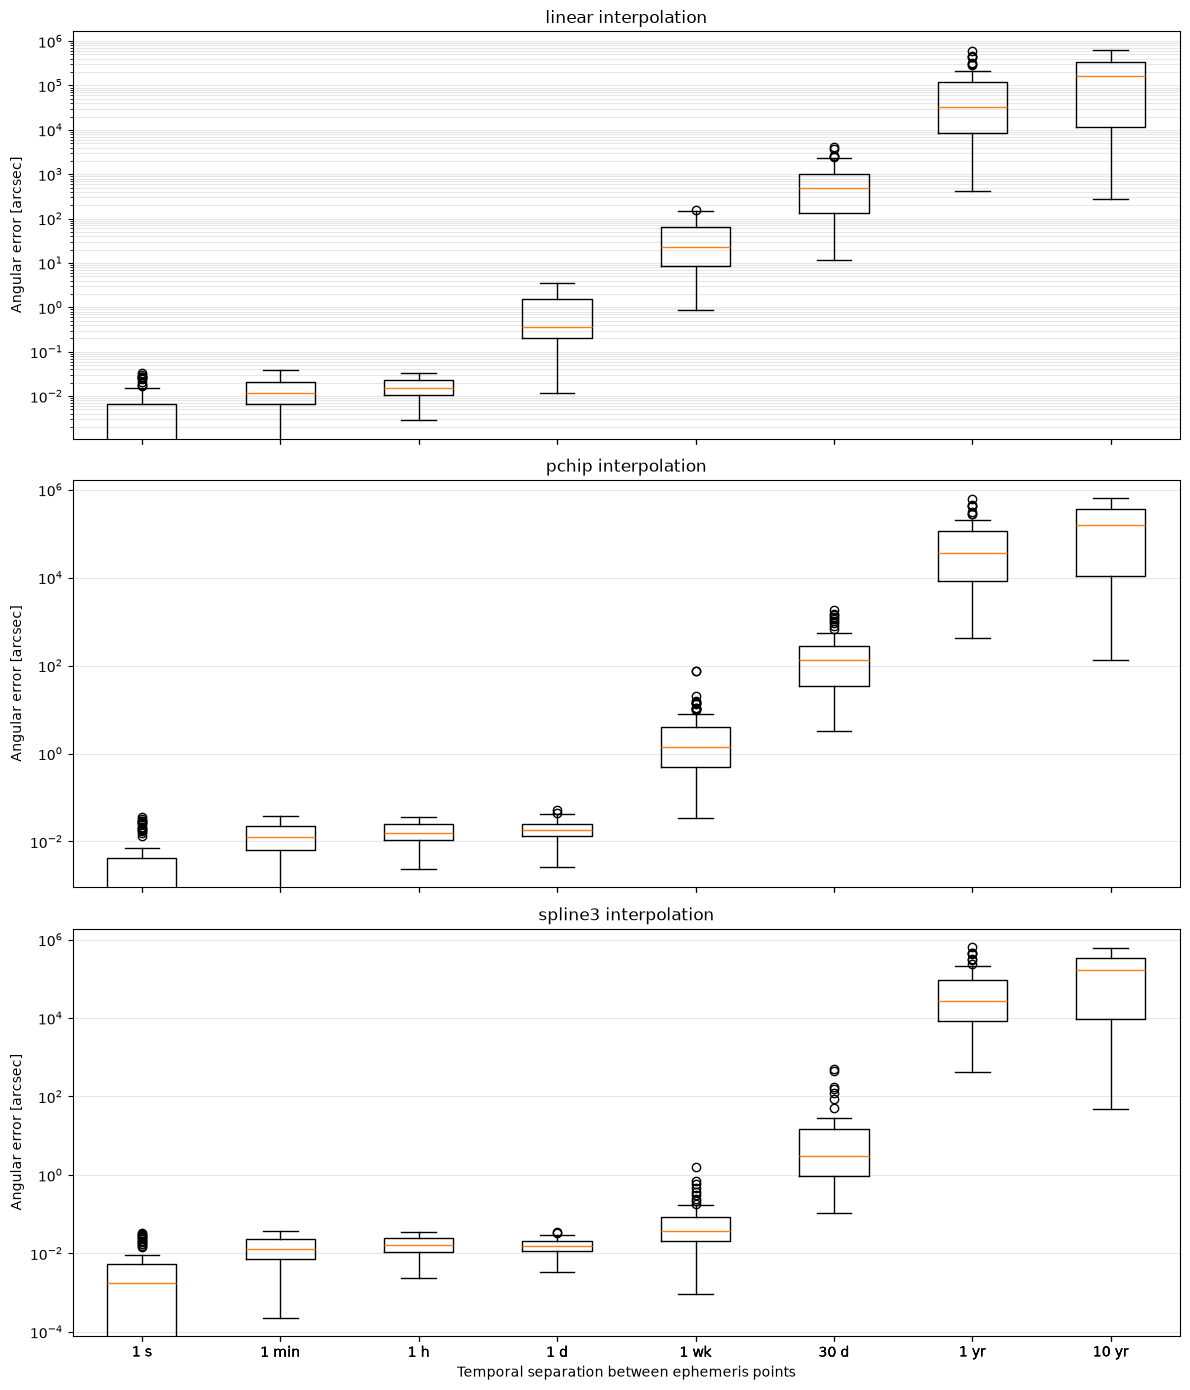

In [30]:
interval_order = [
    "1 s",
    "1 min",
    "1 h",
    "1 d",
    "1 wk",
    "30 d",
    "1 yr",
    "10 yr"
]

interpolations = [
    "linear",
    "pchip",
    "spline3"
]


fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14),
    sharex=True
)


for ax, interpolation in zip(axes, interpolations):

    data = []

    for interval in interval_order:
        values = results.loc[
            (results["interpolation"] == interpolation) &
            (results["interval"] == interval),
            "angular_error_arcsec"
        ]

        data.append(values)

    ax.boxplot(
        data,
        tick_labels=interval_order
    )

    ax.set_yscale("log")

    ax.set_ylabel("Angular error [arcsec]")
    ax.set_title(f"{interpolation} interpolation")

    ax.grid(
        True,
        axis="y",
        which="both",
        alpha=0.3
    )


axes[-1].set_xlabel(
    "Temporal separation between ephemeris points"
)

plt.tight_layout()
plt.show()

In [32]:
median_table = (
    results
    .groupby(["interval", "interpolation"])
    ["angular_error_arcsec"]
    .median()
    .unstack()
)

median_table = median_table.reindex(interval_order)
median_table

interpolation,linear,pchip,spline3
interval,,,
1 s,0.000000,0.000000,0.001765
1 min,0.011875,0.012453,0.012734
1 h,0.015530,0.015745,0.016411
1 d,0.353279,0.018550,0.015158
1 wk,22.854168,1.434939,0.036580
30 d,489.310735,131.783537,3.110381
1 yr,33419.654790,36942.865610,26444.966190
10 yr,160563.331880,160123.237964,167223.987204


d:\Users\andre\Escritorio\Universal\Code\Python\projects\occ\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


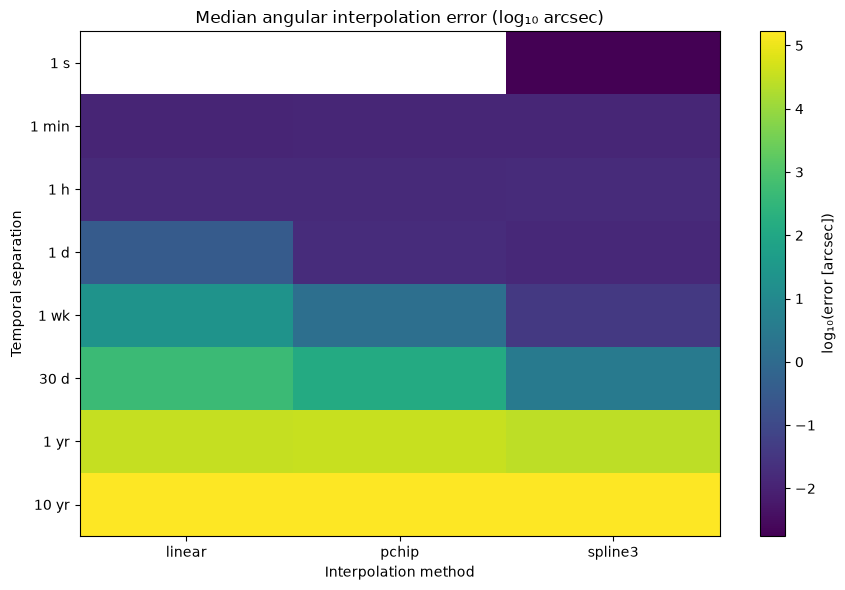

In [33]:
import numpy as np
import matplotlib.pyplot as plt


values = np.log10(median_table)


plt.figure(figsize=(9, 6))

plt.imshow(values, aspect="auto")

plt.xticks(
    range(len(median_table.columns)),
    median_table.columns
)

plt.yticks(
    range(len(median_table.index)),
    median_table.index
)

plt.xlabel("Interpolation method")
plt.ylabel("Temporal separation")

plt.title(
    "Median angular interpolation error (log₁₀ arcsec)"
)

plt.colorbar(
    label="log₁₀(error [arcsec])"
)

plt.tight_layout()
plt.show()